# Generator pseudolosowy oparty na teorii chaosu

Implementacja oparta na pracy: *Patidar, V., & Singh, T. (2025). A novel approach to pseudorandom number generation using Hamiltonian conservative chaotic systems. Frontiers in Physics*

Aby zrozumieć ideę stojącą za tym generatorem (i jego innowacyjność), należy w pierwszej kolejności zrozumieć podstawy teorii chaosu.

## Układy dyssypatywne i HCCS

Wiele popularnych generatorów opartych na teorii chaosu wykorzystuje układy **dyssypatywne** - czyli takie, które z czasem "tracą energię" i zapadają się na tzw. dziwny atraktor. Klasycznym przykładem jest Atraktor Lorenza (zdjęcie poniżej): trajektoria układu wędruje po nim chaotycznie przez długi czas, ale cała dostępna przestrzeń stanów jest ograniczona do tej fraktalnej struktury o niższym wymiarze. Dla generatora liczb losowych oznacza to mniejszą przestrzeń kluczy i potencjalne korelacje statystyczne, a więc zjawiska wysoce niepożądane w zastosowaniach kryptograficznych.

![LorenzAttractor.png](P6-images/LorenzAttractor.png)

### Równania Hamiltona

Układy **Hamiltonowskie (Hamiltonian conservative chaotic systems, HCCS)** opisuje mechanika klasyczna poprzez funkcję energii, zwaną **Hamiltonianem ($H$)**. Ewolucję układu w czasie opisują dwa sprzężone równania różniczkowe wykorzystujące współrzędne położenia i pędu układu.

### Dlaczego to ważne dla PRNG? (Twierdzenie Liouville'a)

Ze wspomnianych równań wynika kluczowa własność: **Twierdzenie Liouville'a**. Mówi ono, że w układzie Hamiltonowskim **objętość przestrzeni fazowej jest zachowana**.

W przeciwieństwie do układów dyssypatywnych, które "zapadają się" do tzw. **dziwnych atraktorów** (ograniczając zbiór dostępnych liczb losowych), układy konserwatywne nie mają atraktorów. Ich trajektorie "wędrują" więc po całej dostępnej przestrzeni. 

Zalety HCCS w kontekście generowania liczb losowych:
1. **Ergodyczność (?):** W asymptotycznym limicie czasowym rozkład odwiedzanych punktów staje się równomierny - każdy obszar przestrzeni fazowej jest odwiedzany z jednakowym prawdopodobieństwem. Autorzy potwierdzają tę własność numerycznie (na histogramach i wykresach przestrzeni fazowej), co dla celów PRNG jest w pełni wystarczające.
2. **Brak atraktorów:** Generator nie "utknie" w pewnym powtarzalnym wzorcu tak łatwo jak klasyczne generatory chaotyczne (nawet czasowo asymptotycznie).
3. **Wysoka czułość na warunki początkowe:** Minimalna zmiana ziarna (seed) powoduje istotnie różne wyniki.

## Architektura generatora w publikacji

Autorzy publikacji jako główny układ chaotyczny zaproponowali **4-wymiarowe równania Eulera dla obracającej się bryły sztywnej**. Cztery wymiary zostały wybrane głównie z uwagi na fakt, że z przestrzeni 4D można wybrać wiele różnych **par zmiennych** do analizy - $(x_1, x_2)$, $(x_1, x_3)$, $(x_2, x_4)$ itd. Każda para tworzy osobny rzut przestrzeni fazowej, a każdy z takich rzutów jest osobnym, niezależnym strumieiem bitów. W efekcie jeden układ 4D dostarcza wielu równoległych schematów generacji o wysokiej jakości statystycznej.

Jednak w sekcji 3. publikacji autorzy prezentują, jak **ta sama metoda ekstrakcji bitów działa dla Mapy Standardowej** (Chirikov Map) - znacznie prostszego, 2-wymiarowego układu hamiltonowskiego. Weryfikują to numerycznie dla parametru $K = 259.14$, uzyskując jednorodny (satysfakcjonujący) rozkład w przestrzeni fazowej.

### Nasza decyzja: Standard Map zamiast równań 4D

W naszej implementacji świadomie wybraliśmy właśnie Mapę Standardową. Rozwiązanie oparate o 4-wymiarowe równania Eulera wymagałoby numerycznego całkowania, co byłoby trudniejsze w implementacji i mniej wydajne w działaniu. Kosztem liczby równoległych "strumieni" generatora (zmniejszając wymiarowość) zaimplementowaliśmy generator w oparciu o prostszy układ hamiltonowski, stosując się do zaleceń autorów publikacji.

### Mapa Standardowa

Wybrany przez nas układ opisują równania:

$$p_{n+1} = (p_n + K \sin(x_n)) \pmod{2\pi}$$
$$x_{n+1} = (x_n + p_{n+1}) \pmod{2\pi}$$

Gdzie parametr $K$ steruje siłą chaosu. Przy $K = 259.14$ (wartość zweryfikowana przez autorów publikacji) układ jest w pełni chaotyczny i wykazuje ergodyczny, równomierny rozkład w przestrzeni fazowej $[0, 2\pi] \times [0, 2\pi]$.

## Kwantyzacja przestrzeni fazowej

Wyobraźmy sobie układ chaotyczny jako małą kauczukową piłeczkę rzuconą w pustym pokoju. Naszym zadaniem jest prześledzenie jej ruchu, tzn. tego, jak i gdzie uderza ona o podłogę z każdym skokiem.

### Układy dyssypatywne

Zwykła piłka rzucona w pokoju z każdym odbiciem od ściany czy podłogi **traci energię** (*dyssypacja*). W końcu piłka zwalnia i zawsze ląduje w jednym określonym miejscu (atraktorze).

### Układy konserwatywne HCCS

*Magiczną piłeczka*, która została umieszczona w pokoju bez tarcia i oporów (np. powietrza), ma natomiast takie cechy: 
1. **Zachowanie energii i objętości:** Piłeczka nigdy nie traci energii, odbija się bez końca.
2. **Ergodyczność:** Odbija się w tak specyficzny sposób, że asymptoptycznie "zmierza" do odwiedzenia **każdego fragmentu podłogi** z równym prawdopodobieństwem. Nie ma w tym przypadku żadnych atraktorów, nie zwalnia, nie wpada w pętle.

### Jak wydobyć bity z "chaosu"?

Aby mapować miejsca "uderzeń piłeczki o podłogę" na zera i jedynki, autorzy publikacji zaproponowali bardzo sprytną metodę. Rysujemy na podłodze układ współrzędnych z pionową osią Y i poziomą osią X. Następnie:

* **Algorytm podstawowy (2 bity):** Podłoga jest podzielona pionową i poziomą linią na 4 ćwiartki. Kiedy piłka spada na ziemię, sprawdzamy, w której ćwiartce wylądowała. Ponieważ ćwiartki są cztery, potrzebujemy dokładnie **2 bitów**, żeby zapisać wynik (00, 01, 10, lub 11).
![2bit_space.png](P6-images/2bit_space.png)

* **Algorytm przyspieszony (3 bity):** Do naszego "krzyża" na podłodze dorysowujemy dwie linie przekątne. Podłoga wygląda teraz jak pizza z 8 kawałkami. Sprawdzając, w który z 8 kawałków wpadła piłeczka (poprzez proste porównanie odległości współrzędnych), z jednego "skoku" (stanu) możemy wydobyć aż **3 bity** naraz (od 000 do 111), co przyspiesza generowanie liczb o 50%, a także pozwala uzyskać wysoką wydajność przy zachowaniu rygorystycznych wymogów testów statystycznych NIST (co autorzy potwierdzili w swojej publikacji).
![3bit_space.png](P6-images/3bit_space.png)

Zatem w naszej implementacji zamieniamy ciągłe wyniki równań fizycznych na bity, stosując podział płaszczyzny fazowej na **8 równych sektorów**.

In [6]:
from ipow.generators import HCCSRNG
from ipow.tests import ValidationConfig, validate_generator, run_visual_tests

import json

cfg = ValidationConfig(n_numbers=5000, n_bits=10000)

{
  "generator": "HCCSRNG",
  "summary_numbers": {
    "count": 5000.0,
    "mean": 9.351601113172808e+18,
    "variance": 2.900259758343687e+37,
    "std": 5.385405981301398e+18,
    "min": 966287193132960.0,
    "max": 1.8446287223090354e+19
  },
  "summary_floats": {
    "count": 5000.0,
    "mean": 0.4942361976671864,
    "variance": 0.08479835899823243,
    "std": 0.29120157794598645,
    "min": 2.2970515662357194e-05,
    "max": 0.9997781554667666
  },
  "bit_balance": {
    "count": 10000,
    "zeros": 5069,
    "ones": 4931,
    "p_zero": 0.5069,
    "p_one": 0.4931
  },
  "serial_pairs": {
    "00": 2586,
    "01": 2482,
    "10": 2483,
    "11": 2448
  },
  "tests": {
    "monobit": {
      "statistic": 1.38,
      "p_value": 0.16758664483002858,
      "pass": true
    },
    "runs": {
      "statistic": 4966.0,
      "p_value": 0.5085597944842315,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 273.39520000000005,
      "p_value": 0.2046562725

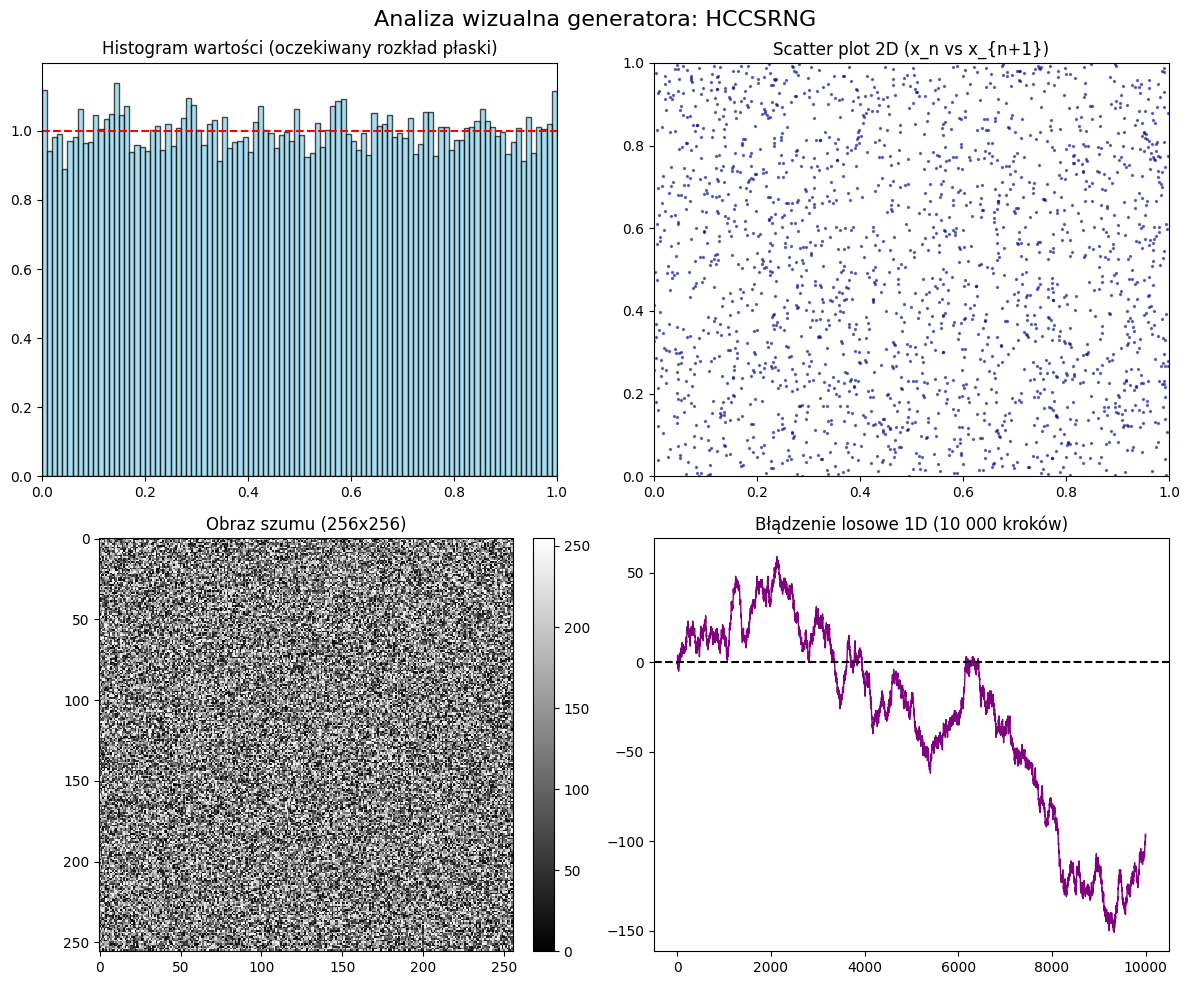

In [5]:
generator = HCCSRNG()
results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))
run_visual_tests(generator)